# 안타 수가 많을수록 홈런 수도 증가하는가?

**분석 목적**: 타자의 안타 수가 홈런 수에 영향을 미치는지 확인한다.

**가설**
- H0(귀무가설): 안타 수는 홈런 수에 영향을 미치지 않는다.
- H1(대립가설): 안타 수가 많을수록 홈런 수도 증가한다.

**데이터 유형**

| 변수 | 유형 | 척도 |
|---|---|---|
| 안타 | 수치형 | 비율척도 |
| 홈런 | 수치형 | 비율척도 |

`타자.csv` 파일을 이 노트북과 같은 폴더에 두고 위에서부터 순서대로 셀을 실행하세요.

## 라이브러리 불러오기 및 설정

In [1]:
import platform
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CSV_PATH = "타자.csv"
MIN_PA = 100        # 최소 타석 기준 (표본 신뢰도 확보)
RANDOM_STATE = 42
TEST_SIZE = 0.2      # 80:20 분할 (70:30을 쓰려면 0.3으로 변경)
CV_FOLDS = 5

### 한글 폰트 자동 설정

In [2]:
system = platform.system()
candidates = {
    "Windows": ["Malgun Gothic"],
    "Darwin": ["AppleGothic"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans CJK JP"],
}.get(system, [])

available = {f.name for f in fm.fontManager.ttflist}
for name in candidates:
    if name in available:
        plt.rcParams["font.family"] = name
        break
else:
    print("경고: 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False

## 데이터 로드 & 전처리

표본 신뢰도를 위해 타석 100 이상인 선수만 남깁니다.

In [3]:
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
print(f"원본 shape: {df.shape}")

df_f = df[df["타석"] >= MIN_PA].reset_index(drop=True)
print(f"타석 {MIN_PA} 이상 필터링 후 shape: {df_f.shape}")
print(f"결측치 개수: {df_f.isna().sum().sum()}")

df_f[["선수", "팀", "타석", "안타", "홈런"]].head()

원본 shape: (398, 48)
타석 100 이상 필터링 후 shape: (155, 48)
결측치 개수: 0


,선수,팀,타석,안타,홈런
0,박찬호,KIA,595,148,5
1,최형우,KIA,549,144,24
2,위즈덤,KIA,486,100,35
3,오선우,KIA,474,116,18
4,김호령,KIA,381,94,6


## 데이터 유형 확인 & 분포 확인

히스토그램, Boxplot, 왜도(skewness)로 안타·홈런의 분포를 살펴봅니다.

In [4]:
skew_hits = stats.skew(df_f["안타"])
skew_hr = stats.skew(df_f["홈런"])
print(f"안타 왜도: {skew_hits:.4f}")
print(f"홈런 왜도: {skew_hr:.4f}  (2 이상이면 심하게 오른쪽으로 치우친 분포)")

안타 왜도: 0.5208
홈런 왜도: 2.0772  (2 이상이면 심하게 오른쪽으로 치우친 분포)


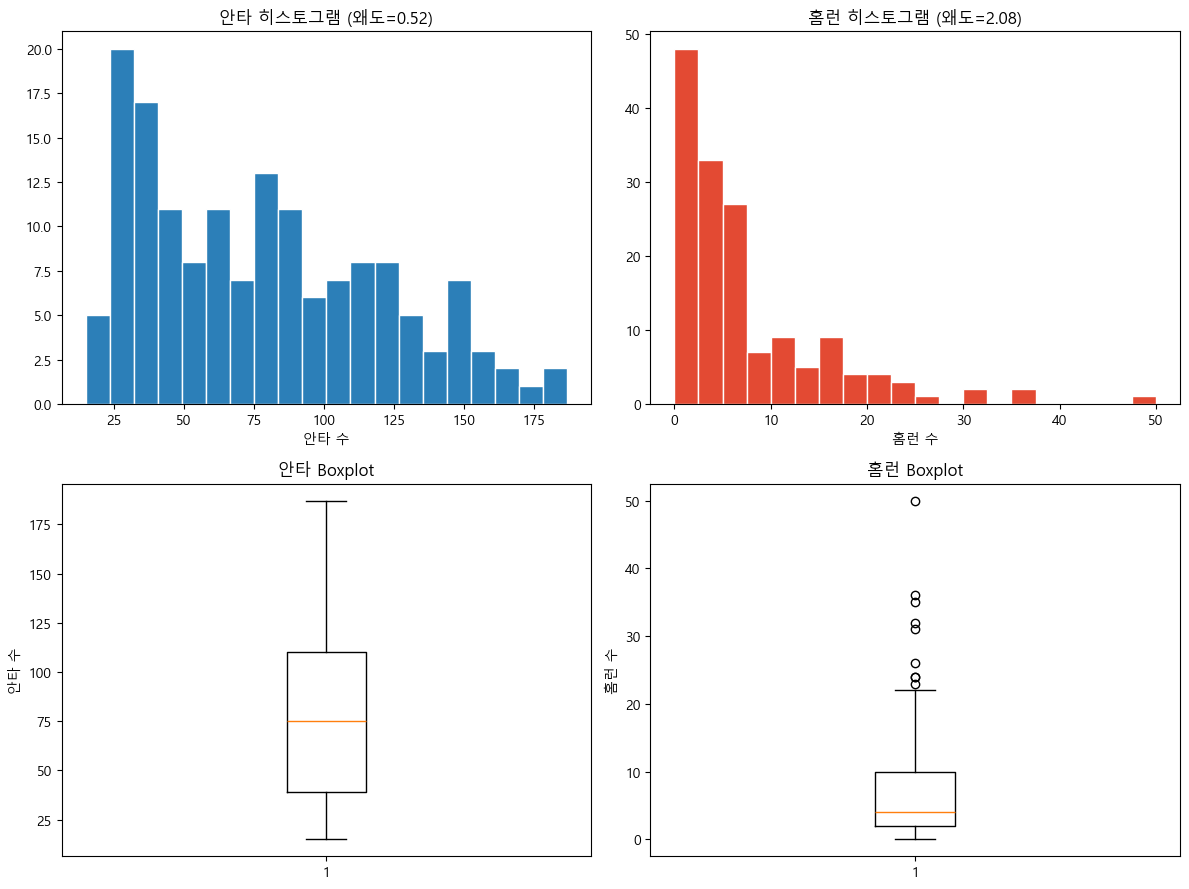

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(df_f["안타"], bins=20, color="#2c7fb8", edgecolor="white")
axes[0, 0].set_title(f"안타 히스토그램 (왜도={skew_hits:.2f})")
axes[0, 0].set_xlabel("안타 수")

axes[0, 1].hist(df_f["홈런"], bins=20, color="#e34a33", edgecolor="white")
axes[0, 1].set_title(f"홈런 히스토그램 (왜도={skew_hr:.2f})")
axes[0, 1].set_xlabel("홈런 수")

axes[1, 0].boxplot(df_f["안타"], vert=True)
axes[1, 0].set_title("안타 Boxplot")
axes[1, 0].set_ylabel("안타 수")

axes[1, 1].boxplot(df_f["홈런"], vert=True)
axes[1, 1].set_title("홈런 Boxplot")
axes[1, 1].set_ylabel("홈런 수")

plt.tight_layout()
plt.savefig("distribution_check.png", dpi=150, bbox_inches="tight")
plt.show()

> 홈런은 오른쪽으로 크게 치우친 분포(왜도 2 이상)이고 이상치(고홈런 타자)도 boxplot에서 확인됩니다.
> 안타는 비교적 완만한 분포입니다.

## 데이터 분할

지도학습(회귀) 문제이므로 Train/Test로 분할합니다 (80:20).

In [7]:
X = df_f[["안타"]]
y = df_f["홈런"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]}명 / Test: {X_test.shape[0]}명 "
      f"({int((1-TEST_SIZE)*100)}:{int(TEST_SIZE*100)})")

Train: 124명 / Test: 31명 (80:20)


## 모델 개발: 선형회귀 vs RandomForestRegressor

두 모델을 학습하고, Test 성능과 5-Fold 교차검증 결과를 함께 비교합니다.

In [ ]:
# CV_FOLDS = 5, RANDOM_STATE = 42
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results = []

- 선형회귀

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

lr_cv_r2 = cross_val_score(lr, X, y, cv=kf, scoring="r2")
lr_cv_mae = -cross_val_score(lr, X, y, cv=kf, scoring="neg_mean_absolute_error")

results.append({
    "모델": "선형회귀",
    "Test MAE": round(lr_mae, 4),
    "Test RMSE": round(lr_rmse, 4),
    "Test R2": round(lr_r2, 4),
    "CV R2 평균": round(lr_cv_r2.mean(), 4),
    "CV R2 표준편차": round(lr_cv_r2.std(), 4),
    "CV MAE 평균": round(lr_cv_mae.mean(), 4),
})

- 랜덤포레스트

In [12]:
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

rf_cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring="r2")
rf_cv_mae = -cross_val_score(rf, X, y, cv=kf, scoring="neg_mean_absolute_error")

results.append({
    "모델": "RandomForestRegressor",
    "Test MAE": round(rf_mae, 4),
    "Test RMSE": round(rf_rmse, 4),
    "Test R2": round(rf_r2, 4),
    "CV R2 평균": round(rf_cv_r2.mean(), 4),
    "CV R2 표준편차": round(rf_cv_r2.std(), 4),
    "CV MAE 평균": round(rf_cv_mae.mean(), 4),
})

In [13]:
results_df = pd.DataFrame(results)
results_df

,모델,Test MAE,Test RMSE,Test R2,CV R2 평균,CV R2 표준편차,CV MAE 평균
0,선형회귀,3.661,5.2888,0.4143,0.3111,0.0938,4.4226
1,RandomForestRegressor,4.084,5.8075,0.2937,-0.0626,0.4333,5.1745


## 성능 평가 결과 시각화

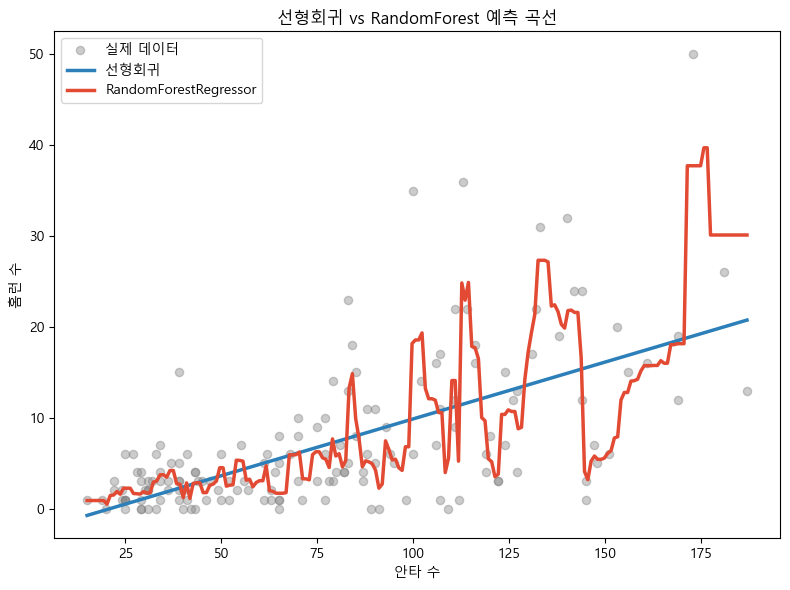

In [14]:
X_line = np.linspace(df_f["안타"].min(), df_f["안타"].max(), 200).reshape(-1, 1)
X_line_df = pd.DataFrame(X_line, columns=["안타"])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_f["안타"], df_f["홈런"], alpha=0.4, color="gray", s=35, label="실제 데이터")

ax.plot(X_line, lr.predict(X_line_df), color="#2c7fb8", linewidth=2.5, label="선형회귀")
ax.plot(X_line, rf.predict(X_line_df), color="#e34a33", linewidth=2.5, label="RandomForestRegressor")

ax.set_xlabel("안타 수")
ax.set_ylabel("홈런 수")
ax.set_title("선형회귀 vs RandomForest 예측 곡선")
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 결론

- **선형회귀**가 Test R²(0.41), 교차검증 R² 평균(0.31) 모두 RandomForest보다 안정적으로 높다.
- **RandomForestRegressor**는 예측 곡선이 train 데이터의 노이즈까지 따라가며(과적합) Test 성능이 더 낮고,
  교차검증 R² 표준편차도 훨씬 크다(0.43) → 변수가 1개뿐인 단순한 관계에서는 오히려 불안정하다.
- 안타-홈런처럼 단일 변수 + 대체로 선형적인 관계에서는 복잡한 모델(RandomForest)보다 단순한 선형회귀가 더 적합하다는 것을 확인했다.

**다음으로 시도해볼 수 있는 것**
- 여러 변수를 추가한 다중회귀/다변량 RandomForest 비교
- 변수를 늘렸을 때 RandomForest의 성능이 선형회귀를 능가하는지 확인